In [1]:
import numpy as np
import dedalus.public as d3
import logging
logger = logging.getLogger(__name__)
import copy
import h5py
import numpy as np
import matplotlib
import re

import matplotlib.pyplot as plt
from dedalus.extras import plot_tools

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

import os
from os import listdir
import math

In [2]:
Lx, Lz = 64,1
Nx, Nz = 4096, 64
# Ra_M = 4e5
D_0 = 0
D_H = 0.5
M_0 = 0
M_H = -0.5
deltaM=-0.05
N_s2=1
Qrad=0.0001
kappa = 0.0001
Prandtl = 1
nu = kappa*Prandtl

dealias = 3/2
dtype = np.float64
coords = d3.CartesianCoordinates('x','z')
dist = d3.Distributor(coords, dtype=dtype)
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)

# Fields
p = dist.Field(name='p', bases=(xbasis,zbasis))
D = dist.Field(name='D', bases=(xbasis,zbasis))
M = dist.Field(name='M', bases=(xbasis,zbasis))
u = dist.VectorField(coords, name='u', bases=(xbasis,zbasis))
Z = dist.Field(name='Z', bases=zbasis)
T = dist.Field(name='T', bases=(xbasis,zbasis))
C = dist.Field(name='C', bases=(xbasis,zbasis))
Qr = dist.Field(name='Q', bases=(xbasis,zbasis))
Nsz = dist.Field(name='Nsz', bases=(xbasis,zbasis))
x,z = dist.local_grids(xbasis,zbasis)

In [3]:
expname = 'MRBC_2D_Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) \
    +'_QR_'+"{:.1e}".format(Qrad) \
    +'_DH_'+"{:.1e}".format(D_H) \
    +'_MH_'+"{:.1e}".format(M_H) \
    +'_deltaM_'+"{:.1e}".format(deltaM) \
    + '_Lx_'+"{:.1e}".format(Lx) \
    + '_Nz_'+"{:d}".format(Nz)

base_dir = '/scratch/zb2113/DedalusData/2D/'
save_dir = base_dir+expname
post_dir= "/home/zb2113/Dedalus-Postanalysis/2D/"
plot_dir = post_dir+ expname
if not os.path.exists(plot_dir):
    os.mkdir(plot_dir)

In [8]:
folder_dir = save_dir+"/snapshots"

file_paths = [os.path.join(folder_dir, file) for file in listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))

#plot the function of total KE
all_tot_ke = []

for file in file_paths:
    with h5py.File(file, mode='r') as file:
        tot_ke = file['tasks']['total KE']
        st = file['scales/sim_time']
        simtime = np.array(st)
        for t in range(0, len(simtime)):
            all_tot_ke.append(np.sum(tot_ke[t]))
print(all_tot_ke[:10])
print(max(all_tot_ke))

print(len(all_tot_ke))
figure_x_axis = np.array([(x*nu/(1**2)) for x in range(1, len(all_tot_ke)+1)])
print(len(figure_x_axis))
plt.plot(figure_x_axis, np.log(all_tot_ke), color = 'blue')
plt.xlabel('Normalized Time')
plt.ylabel('Total Kinetic Energy')
plt.title('Total Kinetic Energy vs normalized time')
plt.savefig(plot_dir+'/Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) 
    +'_QR_'+"{:.1e}".format(Qrad) 
    +'_deltaM_'+"{:.1e}".format(deltaM) +'Total norm KE.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()

plt.plot(np.array(range(len(figure_x_axis))), np.log(all_tot_ke), color = 'blue')
plt.xlabel('time')
plt.ylabel('log Total Kinetic Energy')
plt.title('log Total Kinetic Energy vs regular time')
plt.savefig(plot_dir+'/Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) 
    +'_QR_'+"{:.1e}".format(Qrad) 
    +'_deltaM_'+"{:.1e}".format(deltaM) +'Total KE.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()

[]


ValueError: max() arg is an empty sequence

(0,)
()


/ext3/miniconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/ext3/miniconda3/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: x and y must have same first dimension, but have shapes (1,) and (64,)

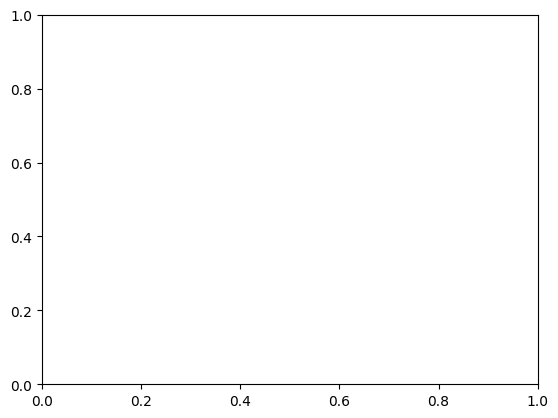

In [9]:
#Plot horizontal avg C
folder_dir = save_dir + "/snapshots"

file_paths = [os.path.join(folder_dir, file) for file in os.listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
# Sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
# Read the last file in the file path
file_paths = file_paths[-400:]
all_clock=[]
for file in file_paths:
    with h5py.File(file, mode='r') as file:
        C = file['tasks']['horizontal avg C'][:,0,:]
        st = file['scales/sim_time']
        simtime = np.array(st)
        for t in range(0, len(simtime)):
            all_clock.append(C[t,:])

all_clock=np.asarray(all_clock)
print(all_clock.shape)
avgC=np.average(all_clock,axis=0)
print(avgC.shape)
z = z.reshape(-1)

plt.plot(avgC, z, color='blue', label='C')

maxC = max(avgC)
plt.axvline(x=maxC, color='black', linestyle='--', label='max C')

# Find the z value corresponding to max C and add a horizontal line
maxC_index = np.argmax(avgC)
z_maxC = z[maxC_index]
plt.axhline(y=z_maxC, color='green', linestyle='--', label='z at max C')

# Annotate the max C and its corresponding z value
plt.text(maxC, 0, f'max C: {maxC:.2f}', horizontalalignment='right', verticalalignment='bottom')
plt.text(0, z_maxC, f'z: {z_maxC:.2f}', horizontalalignment='left', verticalalignment='bottom')

plt.xlabel('C')
plt.ylabel('z')
plt.title('Horizontal avg Clock Tracer')
plt.legend()
plt.savefig(plot_dir +'/Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) 
+'_QR_'+"{:.1e}".format(Qrad) 
+'_deltaM_'+"{:.1e}".format(deltaM) + 'Horizontal avg C.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()
# with h5py.File(file, mode='r') as file:
#     avgC = file['tasks']['horizontal avg C'][-1, 0, :]
#     avgC = np.array(avgC)
#     # avgC = avgC*nu/(1**2) #Normalization
#     z = z.reshape(-1)
#     # Plot the horizontal avg C
#     plt.plot(avgC, z, color='blue', label='C')
    
#     maxC = max(avgC)
#     plt.axvline(x=maxC, color='black', linestyle='--', label='max C')
    
#     # Find the z value corresponding to max C and add a horizontal line
#     maxC_index = np.argmax(avgC)
#     z_maxC = z[maxC_index]
#     plt.axhline(y=z_maxC, color='green', linestyle='--', label='z at max C')
    
#     # Annotate the max C and its corresponding z value
#     plt.text(maxC, 0, f'max C: {maxC:.2f}', horizontalalignment='right', verticalalignment='bottom')
#     plt.text(0, z_maxC, f'z: {z_maxC:.2f}', horizontalalignment='left', verticalalignment='bottom')
    
#     plt.xlabel('C')
#     plt.ylabel('z')
#     plt.title('Horizontal avg Clock Tracer')
#     plt.legend()
#     plt.savefig(plot_dir +'/Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) 
#     +'_QR_'+"{:.1e}".format(Qrad) 
#     +'_deltaM_'+"{:.1e}".format(deltaM) + 'Horizontal avg C.png', dpi=200, bbox_inches='tight')
#     plt.show()
#     plt.clf()

(10000, 64)
(64,)


NameError: name 'avgC' is not defined

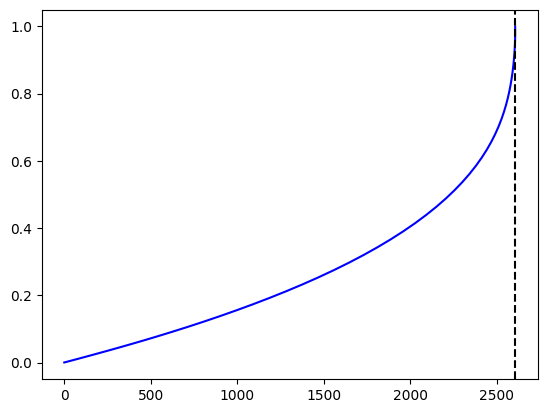

In [5]:

##bottom clock tracer

param_values = [0.0001,0.0002,0.0003,0.0004,0.0005,0.0006,0.0007,0.0008,0.0009,0.0010,0.0011,0.0012]
# param_values = [0.0001,0.0002,0.0004,0.0008,0.0012]
# param_values = [0.0001]
taulist=[]
maxC1list=[]
maxC2list=[]
avgC1list=[]
avgC2list=[]
Nusseltlist=[]
Nu2list=[]
for qrad in param_values:
    Qrad=qrad
    if Qrad!=0:
        tau=0.5/2*np.pi/Qrad
    else:
        tau=0
    taulist.append(tau)
    expname = 'MRBC_2D_Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) \
    +'_QR_'+"{:.1e}".format(Qrad) \
    +'_DH_'+"{:.1e}".format(D_H) \
    +'_MH_'+"{:.1e}".format(M_H) \
    +'_deltaM_'+"{:.1e}".format(deltaM) \
    + '_Lx_'+"{:.1e}".format(Lx) \
    + '_Nz_'+"{:d}".format(Nz)
    
    base_dir = '/scratch/zb2113/DedalusData/2D/'
    save_dir = base_dir+expname
    post_dir= "/home/zb2113/Dedalus-Postanalysis/2D/"
    plot_dir = post_dir+ expname
    if not os.path.exists(plot_dir):
        os.mkdir(plot_dir)
    folder_dir = save_dir + "/snapshots"
    file_paths = [os.path.join(folder_dir, file) for file in os.listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
    # Sort by the number in the file name
    file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
    # Read the last file in the file path
    file_paths = file_paths[-400:]
    all_clock=[]
    dzClist=[]
    Nutimelist=[]
    for file in file_paths:
        with h5py.File(file, mode='r') as file:
            C = file['tasks']['horizontal avg C'][:,0,:]
            dzC = -file['tasks']['diffusive flux of clock tracer'][:,0,:]
            st = file['scales/sim_time']
            
            # Nu2 = np.transpose(file['tasks']['Nusselt Number'][:,:,:])
            Mfluxdiff = -np.transpose(file['tasks']['diffusive flux of moist buoyancy'][:,0,0])
            Dfluxdiff = -np.transpose(file['tasks']['diffusive flux of dry buoyancy'][:,0,0])
            
            Mavgbot = np.transpose(file['tasks']['horizontal avg M'][:,0,0])
            Davgbot = np.transpose(file['tasks']['horizontal avg D'][:,0,0])
            Mavgtop = np.transpose(file['tasks']['horizontal avg M'][:,0,63])
            Davgtop = np.transpose(file['tasks']['horizontal avg D'][:,0,63])
            # print(Mfluxdiff.shape)
            MfluxRe = np.transpose(file['tasks']['Reynolds flux of moist buoyancy'][:,0,0])
            # print(Nu2.shape)
            Nu2 = (Mfluxdiff-1/2*Dfluxdiff)/((Mavgtop-1/2*Davgtop)-(Mavgbot-1/2*Davgbot))/kappa
            
            simtime = np.array(st)
            for t in range(0, len(simtime)):
                all_clock.append(C[t,:])
                dzClist.append(dzC[t,:])
                Nutimelist.append(Nu2[t])
    
    all_clock=np.asarray(all_clock)
    dzClist=np.asarray(dzC[t,:])
    Nutimelist=np.asarray(Nutimelist)
    print(all_clock.shape)
    avgC1=np.average(all_clock,axis=0)
    avgdzC=np.average(dzClist,axis=0)
    avgNu2=np.average(Nutimelist,axis=0)
    Nu2list.append(avgNu2)
    print(avgC1.shape)
    z = z.reshape(-1)

    averageC1=avgC1[-1]
    avgC1list.append(averageC1)
    plt.plot(avgC1, z, color='blue', label='C')
    
    maxC1 = max(avgC1)
    maxC1list.append(maxC1)
    plt.axvline(x=maxC1, color='black', linestyle='--', label='max C')

    # Find the z value corresponding to max C and add a horizontal line
    maxC_index = np.argmax(avgC)
    z_maxC = z[maxC_index]
    plt.axhline(y=z_maxC, color='green', linestyle='--', label='z at max C')
    
    # Annotate the max C and its corresponding z value
    plt.text(maxC1, 0, f'max C1: {maxC1:.2f}', horizontalalignment='right', verticalalignment='bottom')
    plt.text(0, z_maxC, f'z: {z_maxC:.2f}', horizontalalignment='left', verticalalignment='bottom')

    h1=-math.inf
    # print(avgC)
    for i in range(len(z)):
        if dzClist[i]<=0.9:
            h1=z[i]
            break

    plt.axhline(y=h1, color='green', linestyle='-', label='diffusive layer')    
    plt.text(0, h1, f'z: {h1:.5f}', horizontalalignment='left', verticalalignment='bottom')
    
    plt.xlabel('C')
    plt.ylabel('z')
    plt.title('Horizontal avg Clock Tracer')
    plt.legend()
    plt.savefig(plot_dir +'/Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) 
    +'_QR_'+"{:.1e}".format(Qrad) 
    +'_deltaM_'+"{:.1e}".format(deltaM) + 'Horizontal avg C.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.clf()
    all_clock=[]
    for file in file_paths:
        with h5py.File(file, mode='r') as file:
            C = file['tasks']['horizontal avg T'][:,0,:]
            dzC = -file['tasks']['diffusive flux of tracer'][:,0,:]
            st = file['scales/sim_time']
            simtime = np.array(st)
            for t in range(0, len(simtime)):
                all_clock.append(C[t,:])
    
    all_clock=np.asarray(all_clock)
    dzClist=np.asarray(dzC[t,:])
    print(all_clock.shape)
    avgC2=np.average(all_clock,axis=0)
    avgdzC=np.average(dzClist,axis=0)
    print(avgC2.shape)
    z = z.reshape(-1)

    averageC2=avgC2[0]
    avgC2list.append(averageC2)
    plt.plot(avgC2, z, color='blue', label='C')
    
    maxC2 = max(avgC2)
    maxC2list.append(maxC2)
    plt.axvline(x=maxC2, color='black', linestyle='--', label='max C')

    # Find the z value corresponding to max C and add a horizontal line
    maxC_index = np.argmax(avgC2)
    z_maxC = z[maxC_index]
    plt.axhline(y=z_maxC, color='green', linestyle='--', label='z at max C')
    
    # Annotate the max C and its corresponding z value
    plt.text(maxC2, 0, f'max C2: {maxC2:.2f}', horizontalalignment='right', verticalalignment='bottom')
    plt.text(0, z_maxC, f'z: {z_maxC:.2f}', horizontalalignment='left', verticalalignment='bottom')

    h2=-math.inf

    # print(avgC)
    for i in range(len(z)):
        if dzClist[len(z)-1-i]<=0.9:
            h2=z[len(z)-1-i]
            break

    plt.axhline(y=h2, color='green', linestyle='-', label='diffusive layer')    
    plt.text(0, h2, f'z: {h2:.5f}', horizontalalignment='left', verticalalignment='top')
    
    plt.xlabel('C')
    plt.ylabel('z')
    plt.title('Horizontal avg top Clock Tracer')
    plt.legend()
    plt.savefig(plot_dir +'/Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) 
    +'_QR_'+"{:.1e}".format(Qrad) 
    +'_deltaM_'+"{:.1e}".format(deltaM) + 'Horizontal avg top C.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.clf()

    Nu=1/(maxC1+maxC2)/kappa
    Nusseltlist.append(Nu)
plt.plot(param_values,taulist,label='tau')
plt.plot(param_values,maxC1list,label='maxCbot')
plt.plot(param_values,maxC2list,label='maxCtop')
plt.plot(param_values,avgC1list,label='avgCbot')
plt.plot(param_values,avgC2list,label='avgCtop')
plt.ylim(0,2500)
plt.legend()
plt.show()

plt.plot(param_values, Nusseltlist,label='Nu test')
plt.plot(param_values, Nu2list,label='Nu reference')
plt.legend()
plt.show()
print("Compare:",h1/(2*kappa))

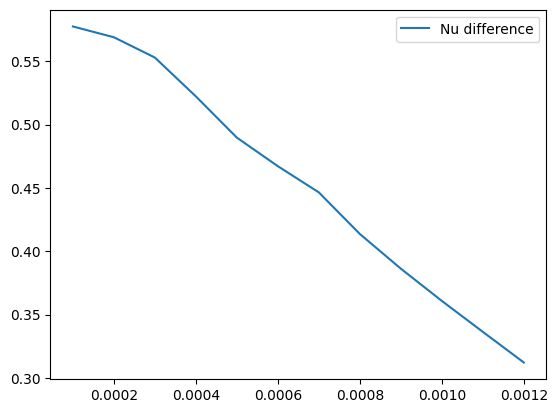

In [11]:

plt.plot(param_values, np.asarray(Nusseltlist)-np.asarray(Nu2list),label='Nu difference')
plt.legend()
plt.show()

In [ ]:
for qrad in param_values:

In [16]:
for i in Nu2list:
    print(np.mean(i))


-1.101633340463845
-1.5753957278842194
-1.264922742949328
-1.1538238310929056
-1.4380871479667328
-1.7028938999973784
-1.3268267086338044
-1.188841198247103
-1.194455567525853
-1.8830873298811566
-1.3685826890918042
-1.2117672500197587
-1.1277842756652463
-1.8699006136722758
-1.431779969608998
-1.2439133224110765
-1.1463923849454782
-1.743717905195776
-1.5463218308130018
-1.2901614736490714
-1.439282833431263
-1.371639991368875
-1.3882547189601733
-1.9806444024335814
-1.3859965154701437
-1.8568226445794953
-1.633700466355228
-1.3218257891389003
-1.984522565933901
-1.5678281778692909
-1.334198455644845
-2.0150981585011896
-1.4923507411615469
-1.4512000647146317
-1.9724682439470733
-1.4432501012287995
-1.6491730473741955
-1.8035148023522547
-1.3974111221675976
-1.870343898667945
-1.5591055333140484
-1.3716985932821866
-2.0813665910090053
-1.5210075113131751
-2.2597170015574535
-1.5857516679451114
-2.1509779676014946
-1.801051352887525
-1.8672500761649224
-1.7957024984354995
-2.0512904696

In [17]:
i.shape

(500,)

In [ ]:
##top clock tracer

taulist=[]
maxClist=[]
avgClist=[]
for qrad in param_values:
    Qrad=qrad
    tau=0.5/2*np.pi/Qrad
    taulist.append(tau)
    expname = 'MRBC_2D_Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) \
    +'_QR_'+"{:.1e}".format(Qrad) \
    +'_DH_'+"{:.1e}".format(D_H) \
    +'_MH_'+"{:.1e}".format(M_H) \
    +'_deltaM_'+"{:.1e}".format(deltaM) \
    + '_Lx_'+"{:.1e}".format(Lx) \
    + '_Nz_'+"{:d}".format(Nz)
    
    base_dir = '/scratch/zb2113/DedalusData/2D/'
    save_dir = base_dir+expname
    post_dir= "/home/zb2113/Dedalus-Postanalysis/2D/"
    plot_dir = post_dir+ expname
    if not os.path.exists(plot_dir):
        os.mkdir(plot_dir)
    folder_dir = save_dir + "/snapshots"
    file_paths = [os.path.join(folder_dir, file) for file in os.listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
    # Sort by the number in the file name
    file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
    # Read the last file in the file path
    file_paths = file_paths[-400:]
    all_clock=[]
    dzClist=[]
    for file in file_paths:
        with h5py.File(file, mode='r') as file:
            C = file['tasks']['horizontal avg T'][:,0,:]
            dzC = -file['tasks']['diffusive flux of tracer'][:,0,:]
            st = file['scales/sim_time']
            simtime = np.array(st)
            for t in range(0, len(simtime)):
                all_clock.append(C[t,:])
    
    all_clock=np.asarray(all_clock)
    dzClist=np.asarray(dzC[t,:])
    print(all_clock.shape)
    avgC=np.average(all_clock,axis=0)
    avgdzC=np.average(dzClist,axis=0)
    print(avgC.shape)
    z = z.reshape(-1)

    averageC=avgC[-1]
    avgClist.append(averageC)
    plt.plot(avgC, z, color='blue', label='C')
    
    maxC2 = max(avgC)
    maxClist.append(maxC2)
    plt.axvline(x=maxC2, color='black', linestyle='--', label='max C')

    # Find the z value corresponding to max C and add a horizontal line
    maxC_index = np.argmax(avgC)
    z_maxC = z[maxC_index]
    plt.axhline(y=z_maxC, color='green', linestyle='--', label='z at max C')
    
    # Annotate the max C and its corresponding z value
    plt.text(maxC2, 0, f'max C2: {maxC2:.2f}', horizontalalignment='right', verticalalignment='bottom')
    plt.text(0, z_maxC, f'z: {z_maxC:.2f}', horizontalalignment='left', verticalalignment='bottom')

    h2=-math.inf

    # print(avgC)
    for i in range(len(z)):
        if dzClist[len(z)-1-i]<=0.9:
            h2=z[len(z)-1-i]
            break

    plt.axhline(y=h2, color='green', linestyle='-', label='diffusive layer')    
    plt.text(0, h2, f'z: {h2:.5f}', horizontalalignment='left', verticalalignment='top')
    
    plt.xlabel('C')
    plt.ylabel('z')
    plt.title('Horizontal avg top Clock Tracer')
    plt.legend()
    plt.savefig(plot_dir +'/Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) 
    +'_QR_'+"{:.1e}".format(Qrad) 
    +'_deltaM_'+"{:.1e}".format(deltaM) + 'Horizontal avg top C.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.clf()
plt.plot(param_values,taulist,label='tau')
plt.plot(param_values,maxClist,label='maxC')
plt.plot(param_values,avgClist,label='avgC')
plt.ylim(0,2500)
plt.legend()
plt.show()


In [ ]:
Nu=2/(h1+h2)
print("Nu:",Nu)
Nu2=1/(maxC1+maxC2)/kappa
print(Nu2)

In [ ]:
# deltaM=-0.05
# param_values = [0.0001,0.0002,0.0003,0.0004,0.0005,0.0006,0.0007,0.0008,0.0009,0.0010,0.0011,0.0012]
# param_values = [0.0001,0.0002,0.0004,0.0008,0.0012]
# taulist=[]
# maxClist=[]
# avgClist=[]
# for qrad in param_values:
#     Qrad=qrad
#     tau=0.5/2*np.pi/Qrad
#     taulist.append(tau)
#     expname = 'MRBC_2D_Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) \
#     +'_QR_'+"{:.1e}".format(Qrad) \
#     +'_DH_'+"{:.1e}".format(D_H) \
#     +'_MH_'+"{:.1e}".format(M_H) \
#     +'_deltaM_'+"{:.1e}".format(deltaM) \
#     + '_Lx_'+"{:.1e}".format(Lx) \
#     + '_Nz_'+"{:d}".format(Nz)
    
#     base_dir = '/scratch/zb2113/DedalusData/2D/'
#     save_dir = base_dir+expname
#     post_dir= "/home/zb2113/Dedalus-Postanalysis/2D/"
#     plot_dir = post_dir+ expname
#     if not os.path.exists(plot_dir):
#         os.mkdir(plot_dir)
#     folder_dir = save_dir + "/snapshots"
#     file_paths = [os.path.join(folder_dir, file) for file in os.listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#     # Sort by the number in the file name
#     file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
#     # Read the last file in the file path
#     file_paths = file_paths[-400:]
#     all_clock=[]
#     for file in file_paths:
#         with h5py.File(file, mode='r') as file:
#             C = file['tasks']['horizontal avg C'][:,0,:]
#             st = file['scales/sim_time']
#             simtime = np.array(st)
#             for t in range(0, len(simtime)):
#                 all_clock.append(C[t,:])
    
#     all_clock=np.asarray(all_clock)
#     print(all_clock.shape)
#     avgC=np.average(all_clock,axis=0)
#     print(avgC.shape)
#     z = z.reshape(-1)

#     averageC=avgC[-1]
#     avgClist.append(averageC)
#     plt.plot(avgC, z, color='blue', label='C')
    
#     maxC = max(avgC)
#     maxClist.append(maxC)
#     plt.axvline(x=maxC, color='black', linestyle='--', label='max C')

#     # Find the z value corresponding to max C and add a horizontal line
#     maxC_index = np.argmax(avgC)
#     z_maxC = z[maxC_index]
#     plt.axhline(y=z_maxC, color='green', linestyle='--', label='z at max C')
    
#     # Annotate the max C and its corresponding z value
#     plt.text(maxC, 0, f'max C: {maxC:.2f}', horizontalalignment='right', verticalalignment='bottom')
#     plt.text(0, z_maxC, f'z: {z_maxC:.2f}', horizontalalignment='left', verticalalignment='bottom')
    
#     plt.xlabel('C')
#     plt.ylabel('z')
#     plt.title('Horizontal avg Clock Tracer')
#     plt.legend()
#     plt.savefig(plot_dir +'/Kappa_'+"{:.1e}".format(kappa) +'_Pr_'+"{:.1e}".format(Prandtl) 
#     +'_QR_'+"{:.1e}".format(Qrad) 
#     +'_deltaM_'+"{:.1e}".format(deltaM) + 'Horizontal avg C.png', dpi=200, bbox_inches='tight')
#     plt.show()
#     plt.clf()
# plt.plot(param_values,taulist,label='tau')
# plt.plot(param_values,maxClist,label='maxC')
# plt.plot(param_values,avgClist,label='avgC')
# plt.ylim(0,2500)
# plt.legend()
# plt.show()

25.401949726071216


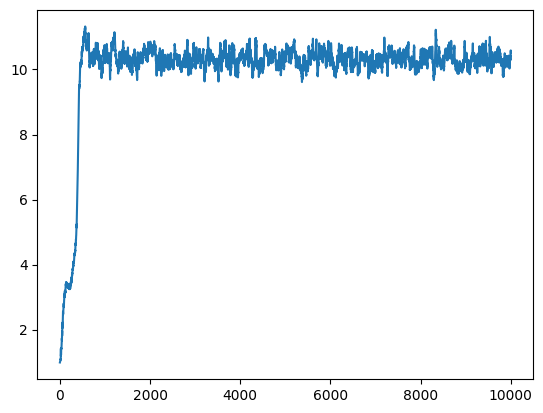

In [10]:
##Nusselt Number
folder_dir = save_dir + "/snapshots"

file_paths = [os.path.join(folder_dir, file) for file in listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
Nu=[]
file_paths = file_paths[-400:]
for file in file_paths:
    with h5py.File(file, mode='r') as file:
        # Nu2 = np.transpose(file['tasks']['Nusselt Number'][:,:,:])
        Mfluxdiff = -np.transpose(file['tasks']['diffusive flux of moist buoyancy'][:,0,0])
        # print(Mfluxdiff.shape)
        MfluxRe = np.transpose(file['tasks']['Reynolds flux of moist buoyancy'][:,0,0])
        # print(Nu2.shape)
        Nu2 = (Lz*Mfluxdiff)/(kappa*(M_H-M_0))
        st = file['scales/sim_time']
        simtime = np.array(st)
        for t in range(0, len(simtime)):
            Nu.append(Nu2[t])
all_clock=[]
for file in file_paths:
    with h5py.File(file, mode='r') as file:
        C = file['tasks']['horizontal avg C'][:,0,:]
        st = file['scales/sim_time']
        simtime = np.array(st)
        for t in range(0, len(simtime)):
            all_clock.append(C[t,:])

all_clock=np.asarray(all_clock)
avgC=np.average(all_clock,axis=0)
z = z.reshape(-1)

maxC = max(avgC)

Nu=np.asarray(Nu)
# Nu=np.average(Nu)
plt.plot(Nu)
# print(Nu)
# with h5py.File(file, mode='r') as file:
#     DC = np.transpose(file['tasks']['diffusive flux of clock tracer'][-1,:,:])
#     CR = np.transpose(file['tasks']['Reynolds flux of clock tracer'][-1,:,:])
#     Nu = 1+CR/(-DC)
#     print(Nu)
#     print(np.average(Nu))
#     Nu2 = np.transpose(file['tasks']['Nusselt Number'][-1,:,:])
#     print(np.average(Nu2))

# print(file_paths)
print(2/(maxC*kappa))

[1.         1.         1.         ... 0.9999924  0.99999675 1.00001835]
['/scratch/zb2113/DedalusData/2D/MRBC_2D_Kappa_1.0e-04_Pr_1.0e+00_QR_1.2e-03_DH_5.0e-01_MH_-5.0e-01_deltaM_0.0e+00_Lx_6.4e+01_Nz_64/snapshots/snapshots_s1.h5', '/scratch/zb2113/DedalusData/2D/MRBC_2D_Kappa_1.0e-04_Pr_1.0e+00_QR_1.2e-03_DH_5.0e-01_MH_-5.0e-01_deltaM_0.0e+00_Lx_6.4e+01_Nz_64/snapshots/snapshots_s2.h5', '/scratch/zb2113/DedalusData/2D/MRBC_2D_Kappa_1.0e-04_Pr_1.0e+00_QR_1.2e-03_DH_5.0e-01_MH_-5.0e-01_deltaM_0.0e+00_Lx_6.4e+01_Nz_64/snapshots/snapshots_s3.h5', '/scratch/zb2113/DedalusData/2D/MRBC_2D_Kappa_1.0e-04_Pr_1.0e+00_QR_1.2e-03_DH_5.0e-01_MH_-5.0e-01_deltaM_0.0e+00_Lx_6.4e+01_Nz_64/snapshots/snapshots_s4.h5', '/scratch/zb2113/DedalusData/2D/MRBC_2D_Kappa_1.0e-04_Pr_1.0e+00_QR_1.2e-03_DH_5.0e-01_MH_-5.0e-01_deltaM_0.0e+00_Lx_6.4e+01_Nz_64/snapshots/snapshots_s5.h5', '/scratch/zb2113/DedalusData/2D/MRBC_2D_Kappa_1.0e-04_Pr_1.0e+00_QR_1.2e-03_DH_5.0e-01_MH_-5.0e-01_deltaM_0.0e+00_Lx_6.4e+01_Nz_64/s

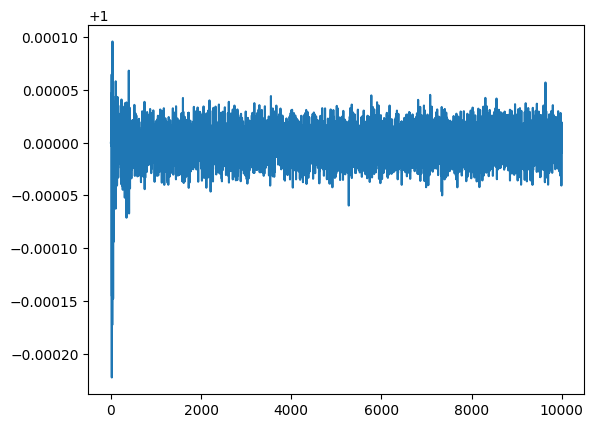

In [11]:
##Nusselt Number
folder_dir = save_dir + "/snapshots"

file_paths = [os.path.join(folder_dir, file) for file in listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
Nu=[]
file_paths = file_paths[-400:]
for file in file_paths:
    with h5py.File(file, mode='r') as file:
        # Nu2 = np.transpose(file['tasks']['Nusselt Number'][:,:,:])
        Mfluxdiff = -np.transpose(file['tasks']['diffusive flux of moist buoyancy'][:,0,0])
        # print(Mfluxdiff.shape)
        MfluxRe = np.transpose(file['tasks']['Reynolds flux of moist buoyancy'][:,0,0])
        # print(Nu2.shape)
        Nu2 = (Mfluxdiff+MfluxRe)/Mfluxdiff
        st = file['scales/sim_time']
        simtime = np.array(st)
        for t in range(0, len(simtime)):
            Nu.append(Nu2[t])
Nu=np.asarray(Nu)
# Nu=np.average(Nu)
plt.plot(Nu)
print(Nu)
# with h5py.File(file, mode='r') as file:
#     DC = np.transpose(file['tasks']['diffusive flux of clock tracer'][-1,:,:])
#     CR = np.transpose(file['tasks']['Reynolds flux of clock tracer'][-1,:,:])
#     Nu = 1+CR/(-DC)
#     print(Nu)
#     print(np.average(Nu))
#     Nu2 = np.transpose(file['tasks']['Nusselt Number'][-1,:,:])
#     print(np.average(Nu2))

print(file_paths)
    

In [12]:
folder_dir = save_dir+"/snapshots"

file_paths = [os.path.join(folder_dir, file) for file in listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
file = file_paths[-1]
with h5py.File(file, mode='r') as file:
    print(list(file.keys()))
    scalekeys=list(file['scales'].keys())
    taskkeys=list(file['tasks'].keys())
    print(scalekeys)
    print(taskkeys)
    #automatic read x y zhash: testing feature
    xhash=scalekeys[-2]
    zhash=scalekeys[-1]
    x=file['scales'][xhash]
    z=file['scales'][zhash]
    x=np.array(x)
    z=np.array(z)

['scales', 'tasks']
['constant', 'iteration', 'sim_time', 'timestep', 'wall_time', 'world_time', 'write_number', 'x_hash_908802857c17940816fda69b86b2cc329b58f05e', 'z_hash_2b3e6c1ad6197e7bbb577c37c9be3babe1727daf']
['Dry derivative', 'Moist derivative', 'Nusselt Number', 'Reynolds flux of clock tracer', 'Reynolds flux of dry buoyancy', 'Reynolds flux of moist buoyancy', 'Reynolds flux of tracer', 'diffusive flux of clock tracer', 'diffusive flux of dry buoyancy', 'diffusive flux of moist buoyancy', 'diffusive flux of tracer', 'diffusive flux of water', 'horizontal avg B', 'horizontal avg C', 'horizontal avg D', 'horizontal avg M', 'horizontal avg T', 'horizontal avg liquid', 'horizontal avg uz', 'horizontal avg vertical B flux', 'horizontal avg vertical C flux', 'horizontal avg vertical D flux', 'horizontal avg vertical M flux', 'horizontal avg vertical T flux', 'horizontal avg vertical lq flux', 'total KE']


In [13]:
#Plot C
folder_dir = save_dir+"/snapshots"

file_paths = [os.path.join(folder_dir, file) for file in listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
#read the last file in the file path
file = file_paths[-1]
with h5py.File(file, mode='r') as file:
    C = np.transpose(file['tasks']['C'][-1,:,:])
    plt.contourf(x, z , C, cmap='RdBu_r')
    plt.colorbar(label='Clock Time')
    plt.xlabel('x')
    plt.ylabel('z')
    plt.title('Clock Time at t=2400')
    plt.show()
    plt.savefig(plot_dir+'/C.png', dpi=200, bbox_inches='tight')
    plt.clf()


KeyError: "Unable to open object (object 'C' doesn't exist)"

In [ ]:
#time evolution of horizontal avg clock tracer
folder_dir = save_dir+"/snapshots"
if not os.path.exists(plot_dir+'/horizontalavgCgraph'):
    os.mkdir(plot_dir+'/horizontalavgCgraph')

file_paths = [os.path.join(folder_dir, file) for file in listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
C=[]
stime=[]
for file in file_paths:
    with h5py.File(file, mode='r') as file:
        avgC = file['tasks']['horizontal avg C']
        st = np.array(file['scales/sim_time'])
        stime.append(st)
        avgC = avgC[:,0,:]
        C.append(avgC)
# contour plot of horizontal avg C with z and time
stime=np.array(stime)
stime = np.concatenate(stime).flatten()
C = np.concatenate(C, axis=0)
C = np.transpose(C)
C = C*nu/(1**2) #Normalization
print(stime)
t_grid, Z_grid = np.meshgrid(stime, z)
plt.figure(figsize=(64, 8), dpi=300)
plt.contourf(t_grid,Z_grid,C, cmap='RdBu_r',levels=100)
plt.colorbar(label='C')
plt.xlabel('t')
plt.ylabel('z')
plt.title('Horizontal avg Clock Tracer')
plt.savefig(plot_dir+'/horizontalavgCgraph/tevoC.png', dpi=300, bbox_inches='tight')
plt.show()

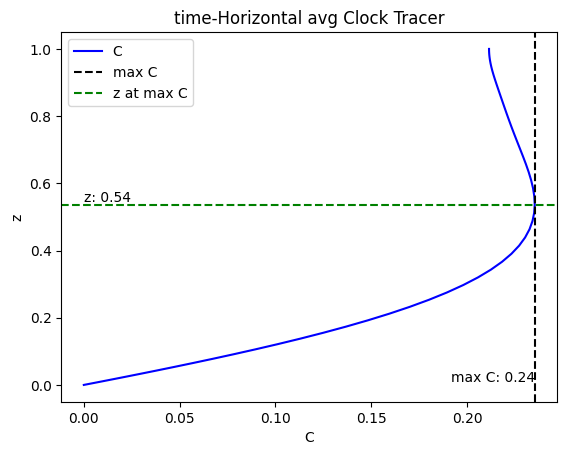

<Figure size 640x480 with 0 Axes>

In [3]:
#Plot time-horizontal avg C
folder_dir = save_dir + "/snapshots"
file_paths = [os.path.join(folder_dir, file) for file in os.listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
# Sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))

barC=np.zeros(Nz)
count=0
for file in file_paths:
    with h5py.File(file, mode='r') as file:
        count=count+1
        simtime = np.array(file['scales/sim_time'])
        for t in range(0, len(simtime)):
            avgC = file['tasks']['horizontal avg C'][t, 0, :]
            avgC = np.array(avgC)
            
        #averaging
        avgC = avgC/len(simtime)
        barC+=avgC

barC = barC/count
barC = barC*nu/(1**2) #Normalization
z = z.reshape(-1)
# Plot the horizontal avg C
plt.plot(barC, z, color='blue', label='C')

maxC = max(barC)
plt.axvline(x=maxC, color='black', linestyle='--', label='max C')

# Find the z value corresponding to max C and add a horizontal line
maxC_index = np.argmax(barC)
z_maxC = z[maxC_index]
plt.axhline(y=z_maxC, color='green', linestyle='--', label='z at max C')

# Annotate the max C and its corresponding z value
plt.text(maxC, 0, f'max C: {maxC:.2f}', horizontalalignment='right', verticalalignment='bottom')
plt.text(0, z_maxC, f'z: {z_maxC:.2f}', horizontalalignment='left', verticalalignment='bottom')

plt.xlabel('C')
plt.ylabel('z')
plt.title('time-Horizontal avg Clock Tracer')
plt.legend()
plt.savefig(plot_dir + '/time-Horizontal avg C.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()